# Set Up and Load Data

In [1]:
# setup
import pandas as pd
import numpy as np
import random
from scipy import sparse
from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.proportion import confint_proportions_2indep
import pingouin as pg
from cliffs_delta import cliffs_delta
import anndata as ad
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

seed = 0 # random seed for reproducibility
np.random.seed(seed) # set np seed
random.seed(seed) # set random seed


data_folder = "../data_preprocessed/"

In [2]:
# set headers from adatas
cluster_headers = {"bm" : "Curated_annotation",
                  "breast" : "level2",
                  "kidney" : "subclass.full",
                  "liver" : "Curated_annotation",
                  "lung" : "ann_finest_level",
                  "m1" : "cluster_id",
                  "mtg" : "cluster_id",
                  "retina" : "author_cell_type",
                  "spc" : "ThirdAnnotation"
                  }

genetype_headers = {"bm" : "feature_type",
                   "breast" : "feature_type",
                   "kidney" : "feature_type",
                   "liver" : "feature_type",
                   "lung" : "feature_type",
                   "m1" : "biotype",
                   "mtg" : "biotype",
                   "retina" : "feature_type",
                   "spc" : "feature_type"
                   }


In [3]:
# prefix library
prefixes = {"bm" : "data_bm",
            "breast" : "data_breast_ds_filter",
            "kidney" : "data_kidney_ds_filter",
            "liver" : "data_liver",
            "lung" : "data_lung_ds",
            "m1" : "data_m1_ds",
            "mtg" : "data_mtg_ds",
            "retina" : "data_retina_all_ds",
            "spc" : "data_spc_ds"
            }

# make subsets
full_adatas = {}
lnc_adatas = {}
coding_adatas = {}
for tissue in prefixes:
    print("Tissue:", tissue)

    # full adatas
    full_adata = sc.read_h5ad(data_folder + prefixes[tissue] + "_preprocessed.h5ad", backed = "r")
    full_adatas[tissue] = full_adata

    # lnc adatas
    lncrna_mask = full_adata.var[genetype_headers[tissue]].isin(["lncRNA"])
    lnc_adata = full_adata[:, lncrna_mask]
    lnc_adatas[tissue] = lnc_adata

    # coding adatas
    coding_mask = full_adata.var[genetype_headers[tissue]].isin(["protein_coding"])
    coding_adata = full_adata[:, coding_mask]
    coding_adatas[tissue] = coding_adata


Tissue: bm
Tissue: breast
Tissue: kidney
Tissue: liver
Tissue: lung
Tissue: m1
Tissue: mtg
Tissue: retina
Tissue: spc


# Validating Data

In [4]:
# print info
print("##### FULL SET #####")
for tissue in full_adatas:
    print(f"-- {tissue} --")
    print(full_adatas[tissue])

print("##### lncRNA SUBSET #####")
for tissue in lnc_adatas:
    print(f"-- {tissue} --")
    print(lnc_adatas[tissue])

print("##### CODING SUBSET #####")
for tissue in coding_adatas:
    print(f"-- {tissue} --")
    print(coding_adatas[tissue])

##### FULL SET #####
-- bm --
AnnData object with n_obs × n_vars = 66613 × 6474 backed at '../data_preprocessed/data_bm_preprocessed.h5ad'
    obs: 'Dataset', 'donor_id', 'suspension_type', 'Original_annotation', 'CellHint_harmonised_group', 'Curated_annotation', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'exist_in_Tabula2022', 'exist_in_DominguezConde2022', 'exist_in_Roy2021', 'exist_in_He2020', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'dendrogram_Curated_annotation', 'is_pre_analysis', 'log1p', 'organism', 'organism_ontology_term_id', 'pca', '

In [5]:
# double checking that lncRNA and protein-coding positive gene sets are subset of full positive gene set
for tissue in full_adatas:
    print(f"-- {tissue} --")
    var_name = "gene" if tissue in ['m1', 'mtg'] else "feature_name"

    lnc_len = len(lnc_adatas[tissue].var[var_name])
    int_len_lnc = len(list(set(full_adatas[tissue].var[var_name]).intersection(set(lnc_adatas[tissue].var[var_name]))))

    coding_len = len(coding_adatas[tissue].var[var_name])
    int_len_coding = len(list(set(full_adatas[tissue].var[var_name]).intersection(set(coding_adatas[tissue].var[var_name]))))

    print(f"lncRNA Count: {lnc_len}\nIntersection Count: {int_len_lnc}")
    print("All lncRNA in Full Positive Gene Set:", lnc_len == int_len_lnc)

    print(f"Coding Count: {coding_len}\nIntersection Count: {int_len_coding}")
    print("All Coding in Full Positive Gene Set:", coding_len == int_len_coding)

-- bm --
lncRNA Count: 79
Intersection Count: 79
All lncRNA in Full Positive Gene Set: True
Coding Count: 6367
Intersection Count: 6367
All Coding in Full Positive Gene Set: True
-- breast --
lncRNA Count: 64
Intersection Count: 64
All lncRNA in Full Positive Gene Set: True
Coding Count: 4550
Intersection Count: 4550
All Coding in Full Positive Gene Set: True
-- kidney --
lncRNA Count: 203
Intersection Count: 203
All lncRNA in Full Positive Gene Set: True
Coding Count: 5036
Intersection Count: 5036
All Coding in Full Positive Gene Set: True
-- liver --
lncRNA Count: 41
Intersection Count: 41
All lncRNA in Full Positive Gene Set: True
Coding Count: 3031
Intersection Count: 3031
All Coding in Full Positive Gene Set: True
-- lung --
lncRNA Count: 83
Intersection Count: 83
All lncRNA in Full Positive Gene Set: True
Coding Count: 5195
Intersection Count: 5195
All Coding in Full Positive Gene Set: True
-- m1 --
lncRNA Count: 262
Intersection Count: 262
All lncRNA in Full Positive Gene Set: T

In [6]:
len(lnc_adatas['bm'].var['feature_name'])

79

# Functions

In [7]:
# extract gene-cluster values of interest
def extract_adata_values_og(full_adatas: dict, lnc_adatas: dict, cluster_headers: dict, to_print: bool = True):
    """
    Args:
        full_adatas (dict): Contains `tissue (str)` : `full adata (ad.AnnData)` KVPs.
        lnc_adatas (dict): Contains `tissue (str)` : `subset adata (ad.AnnData)` KVPs.
        cluster_headers (dict): Contains `tissue (str)` : `column with cluster headers (str)`
        score_of_interest (str): either "median" or "binary_score".
        to_print (bool): Whether to print progress statements. Defaults to True.

    Returns:
        pd.DataFrame: Full dataframe with .
    """

    # assert that tissues in full_adatas are in lnc_adatas and cluster_headers
    for tissue in full_adatas:
        assert((tissue in lnc_adatas) and (tissue in cluster_headers) and (tissue in coding_adatas),
               f"The tissue {tissue} in full_adatas is not within lnc_adatas or cluster_headers.")

    # extract median expression vals
    dfs = []

    for tissue in full_adatas:
        for label, adata in [("Full", full_adatas[tissue]),
                            ("lncRNA", lnc_adatas[tissue])]:
            
            if to_print: print(f"Processing {tissue} Data: {label} set...")
            median_df = (
                adata.varm[f"medians_{cluster_headers[tissue]}"]
                .stack()
                .rename("median")
                .reset_index()
            )
            median_df.columns = ["gene", "cluster", "median"]

            binary_score_df = (
                adata.varm[f"binary_scores_{cluster_headers[tissue]}"]
                .stack()
                .rename("binary_score")
                .reset_index()
            )
            binary_score_df.columns = ["gene", "cluster", "binary_score"]
            
            df = pd.merge(median_df, binary_score_df, on=["gene", "cluster"])

            df["tissue"] = tissue
            df["gene_set"] = label

            if tissue in ["bm", "breast", "kidney", "liver", "lung"]:
                df["type"] = "Non-Neural"
            else:
                df["type"] = "Neural"

            dfs.append(df)

    # full df
    df = pd.concat(dfs, ignore_index=True)
    df["is_zero_median"] = df["median"].apply(lambda x: 'zero' if x == 0 else 'nonzero')
    df["is_zero_binary_score"] = df["binary_score"].apply(lambda x: 'zero' if x == 0 else 'nonzero')

    # return full df
    return df

<>:17: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:17: SyntaxWarning: assertion is always true, perhaps remove parentheses?
/var/folders/rw/9fyg4j2j0m3_p2135vzyk8w0000dq_/T/ipykernel_21816/3558644631.py:17: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert((tissue in lnc_adatas) and (tissue in cluster_headers) and (tissue in coding_adatas),


In [8]:
# extract gene-cluster values of interest
def extract_adata_values(full_adatas: dict, lnc_adatas: dict, coding_adatas: dict, cluster_headers: dict, to_print: bool = True):
    """
    Args:
        full_adatas (dict): Contains `tissue (str)` : `full adata (ad.AnnData)` KVPs.
        lnc_adatas (dict): Contains `tissue (str)` : `subset adata (ad.AnnData)` KVPs.
        coding_adatas (dict): Contains `tissue (str)` : `subset adata (ad.AnnData)` KVPs.
        cluster_headers (dict): Contains `tissue (str)` : `column with cluster headers (str)`
        score_of_interest (str): either "median" or "binary_score".
        to_print (bool): Whether to print progress statements. Defaults to True.

    Returns:
        pd.DataFrame: Full dataframe with .
    """

    # assert that tissues in full_adatas are in lnc_adatas and cluster_headers
    for tissue in full_adatas:
        assert((tissue in lnc_adatas) and (tissue in cluster_headers) and (tissue in coding_adatas),
               f"The tissue {tissue} in full_adatas is not within lnc_adatas or cluster_headers.")

    # extract median expression vals
    dfs = []

    

    for tissue in full_adatas:
        for label, adata in [("Full", full_adatas[tissue]),
                            ("lncRNA", lnc_adatas[tissue]),
                            ("Coding", coding_adatas[tissue])]:
            
            if to_print: print(f"Processing {tissue} Data: {label} set...")
            median_df = (
                adata.varm[f"medians_{cluster_headers[tissue]}"]
                .stack()
                .rename("median")
                .reset_index()
            )
            median_df.columns = ["gene", "cluster", "median"]

            binary_score_df = (
                adata.varm[f"binary_scores_{cluster_headers[tissue]}"]
                .stack()
                .rename("binary_score")
                .reset_index()
            )
            binary_score_df.columns = ["gene", "cluster", "binary_score"]
            
            df = pd.merge(median_df, binary_score_df, on=["gene", "cluster"])

            df["tissue"] = tissue
            df["gene_set"] = label

            if tissue in ["bm", "breast", "kidney", "liver", "lung"]:
                df["type"] = "Non-Neural"
            else:
                df["type"] = "Neural"

            dfs.append(df)

    # full df
    df = pd.concat(dfs, ignore_index=True)
    df["is_zero_median"] = df["median"].apply(lambda x: 'zero' if x == 0 else 'nonzero')
    df["is_zero_binary_score"] = df["binary_score"].apply(lambda x: 'zero' if x == 0 else 'nonzero')

    # return full df
    return df

<>:18: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:18: SyntaxWarning: assertion is always true, perhaps remove parentheses?
/var/folders/rw/9fyg4j2j0m3_p2135vzyk8w0000dq_/T/ipykernel_21816/2984681909.py:18: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert((tissue in lnc_adatas) and (tissue in cluster_headers) and (tissue in coding_adatas),


In [9]:
def compare_gene_sets_og(df: pd.DataFrame, score_of_interest: str, group_col = None):
    """

    Args:
        df (pd.DataFrame): Dataframe containing full values.
        score_of_interest (str): Score of interest to describe.
        group_col (_type_, optional): Stratifying column. Defaults to None.

    Raises:
        ValueError: Validates that score_of_interest is either median or binary_score.

    Returns:
        pd.Dataframe: Contains
    """

    valid = {"median", "binary_score"}
    if score_of_interest not in valid:
        raise ValueError("score_of_interest must be one of %r." % valid)  
    
    if group_col is None:
        groups = [("All", df)]
    else:
        groups = list(df.groupby(group_col))
    
    results = []

    for group_name, sub in groups:
        full = sub[sub["gene_set"] == "Full"]
        lnc = sub[sub["gene_set"] == "lncRNA"]

        # zero proportions
        full_zero = (full[score_of_interest] == 0).mean()
        lnc_zero = (lnc[score_of_interest] == 0).mean()
        
        # delta_prop_ci = confint_proportions_2indep(
        #     count1 = len(lnc[lnc[f"is_zero_{score_of_interest}"] == "zero"]),
        #     nobs1 = len(lnc),
        #     count2 = len(full[full[f"is_zero_{score_of_interest}"] == "zero"]),
        #     nobs2 = len(full),
        #     method = "newcomb"
        # )
        
        # non-zero values
        full_nonzero = full.loc[full[score_of_interest] > 0, score_of_interest]
        lnc_nonzero = lnc.loc[lnc[score_of_interest] > 0, score_of_interest]

        full_mean = full_nonzero.mean()
        lnc_mean = lnc_nonzero.mean()
        full_median = full_nonzero.median()
        lnc_median = lnc_nonzero.median()

        # effect sizes
        cohens_d_lnc = pg.compute_effsize(lnc_nonzero,
                                          full_nonzero,
                                          eftype="cohen")
        cliff_d_lnc, _ = cliffs_delta(lnc_nonzero,
                                      full_nonzero)
        
        # append to results
        results.append({
            "group" : group_name,
            "zero_prop_full" : full_zero,
            "zero_prop_lncRNA" : lnc_zero,
            "delta_prop_lnc_full" : lnc_zero - full_zero,
            "mean_nonzero_full" : full_mean,
            "mean_nonzero_lncRNA" : lnc_mean,
            "median_nonzero_full" : full_median,
            "median_nonzero_lncRNA" : lnc_median,
            "cohens_d_lnc_full" : cohens_d_lnc,
            "cliff_d_lnc_full" : cliff_d_lnc,
        })

    return pd.DataFrame(results)
        

In [10]:
def compare_gene_sets(df: pd.DataFrame, score_of_interest: str, group_col = None):
    """_summary_

    Args:
        df (pd.DataFrame): Dataframe containing full values.
        score_of_interest (str): Score of interest to describe.
        group_col (_type_, optional): Stratifying column. Defaults to None.

    Raises:
        ValueError: Validates that score_of_interest is either median or binary_score.

    Returns:
        pd.Dataframe: Contains
    """

    valid = {"median", "binary_score"}
    if score_of_interest not in valid:
        raise ValueError("score_of_interest must be one of %r." % valid)  
    
    if group_col is None:
        groups = [("All", df)]
    else:
        groups = list(df.groupby(group_col))
    
    results = []

    for group_name, sub in groups:
        full = sub[sub["gene_set"] == "Full"]
        lnc = sub[sub["gene_set"] == "lncRNA"]
        coding = sub[sub["gene_set"] == "Coding"]

        # zero proportions
        full_zero = (full[score_of_interest] == 0).mean()
        lnc_zero = (lnc[score_of_interest] == 0).mean()
        coding_zero = (coding[score_of_interest] == 0).mean()
        
        # delta_prop_ci = confint_proportions_2indep(
        #     count1 = len(lnc[lnc[f"is_zero_{score_of_interest}"] == "zero"]),
        #     nobs1 = len(lnc),
        #     count2 = len(full[full[f"is_zero_{score_of_interest}"] == "zero"]),
        #     nobs2 = len(full),
        #     method = "newcomb"
        # )
        
        # non-zero values
        full_nonzero = full.loc[full[score_of_interest] > 0, score_of_interest]
        lnc_nonzero = lnc.loc[lnc[score_of_interest] > 0, score_of_interest]
        coding_nonzero = coding.loc[coding[score_of_interest] > 0, score_of_interest]

        full_mean = full_nonzero.mean()
        lnc_mean = lnc_nonzero.mean()
        coding_mean = coding_nonzero.mean()
        full_median = full_nonzero.median()
        lnc_median = lnc_nonzero.median()
        coding_median = coding_nonzero.median()

        # effect sizes
        cohens_d_lnc = pg.compute_effsize(lnc_nonzero,
                                          full_nonzero,
                                          eftype="cohen")
        cliff_d_lnc, _ = cliffs_delta(lnc_nonzero,
                                      full_nonzero)
        cohens_d_coding = pg.compute_effsize(coding_nonzero,
                                             full_nonzero,
                                             eftype="cohen")
        cliff_d_coding, _ = cliffs_delta(coding_nonzero,
                                         full_nonzero)
        cohens_d_lnc_coding = pg.compute_effsize(lnc_nonzero,
                                                 coding_nonzero,
                                                 eftype="cohen")
        cliff_d_lnc_coding, _ = cliffs_delta(lnc_nonzero,
                                             coding_nonzero)
        
        # append to results
        results.append({
            "group" : group_name,
            "zero_prop_full" : full_zero,
            "zero_prop_lncRNA" : lnc_zero,
            "zero_prop_coding" : coding_zero,
            "delta_prop_lnc_full" : lnc_zero - full_zero,
            "delta_prop_coding_full" : coding_zero - full_zero,
            "delta_prop_lnc_coding" : lnc_zero - coding_zero,
            "mean_nonzero_full" : full_mean,
            "mean_nonzero_lncRNA" : lnc_mean,
            "mean_nonzero_coding" : coding_mean,
            "median_nonzero_full" : full_median,
            "median_nonzero_lncRNA" : lnc_median,
            "median_nonzero_lncRNA" : coding_median,
            "cohens_d_lnc_full" : cohens_d_lnc,
            "cliff_d_lnc_full" : cliff_d_lnc,
            "cohens_d_coding_full" : cohens_d_coding,
            "cliff_d_coding_full" : cliff_d_coding,
            "cohens_d_lnc_coding" : cohens_d_lnc_coding,
            "cliff_d_lnc_coding" : cliff_d_lnc_coding,
        })

    return pd.DataFrame(results)
        

In [11]:
# make a faceted ridge plot
def facet_ridge(df: pd.DataFrame, score_of_interest: str, facet_by: str = "tissue", hue_name: str = "gene_set", save: bool = False):
    """
    Args:
        df (pd.DataFrame): Dataframe containing scores and categories to plot.
        score_of_interest (str): Score to plot; either "median" or "binary_score".
        facet_by (str, optional): Column to facet plots by. Defaults to "tissue".
        hue_name (str, optional): Color to color KDE curves by. Defaults to "gene_set".
        save (bool, optional): Saves the resulting KDE plot. Defaults to False.

    Raises:
        ValueError: score_of_interest must be either "median" or "binary_score".
        ValueError: score_of_interest must be a column within the passed df.
    """

    add_threshold_lines = False # manual toggle

    # make sure the score of interest is valid
    valid = {"median", "binary_score"}
    if score_of_interest not in valid:
        raise ValueError("score_of_interest must be one of %r." % valid)  

    # make sure that the passed score of interest is within df
    if score_of_interest not in df.columns:
        raise ValueError("score_of_interest must be within df columns.")
    
    # print warning if a zero-containing df is passed
    if "zero" in df[f"is_zero_{score_of_interest}"]:
        print("WARNING: Dataframe containing zero-values has been passed.")

    # make facet outline
    g = sns.FacetGrid(
        df.loc[df[f"is_zero_{score_of_interest}"] == "nonzero"],
        row = facet_by,
        hue = hue_name,
        aspect = 3 if score_of_interest == "binary_score" else 3,
        height = 2,
        sharex = False,
        sharey = False
    )

    # map kde plots to facets
    g.map(
        sns.kdeplot,
        score_of_interest,
        fill = True,
        alpha = 0.4,
        linewidth = 1,
        common_norm = False,
        cut = 0 if score_of_interest == "binary_score" else 0
    )

    # add threshold lines
    if score_of_interest == "binary_score" and add_threshold_lines:
        thresholds = (
            df
            .groupby(["tissue", "gene_set"])[score_of_interest]
            .agg(["mean", "std"])
            .assign(threshold=lambda x: x["mean"] + (2*x["std"]))
            .reset_index()
        )
        print(thresholds.head())

        palette = dict(zip(
            df["gene_set"].unique(),
            sns.color_palette(n_colors=2)
        ))

        for ax, tissue in zip(g.axes.flat, df["tissue"].unique()):
            tissue_thresh = thresholds.query("tissue == @tissue")
            for _, row in tissue_thresh.iterrows():
                ax.axvline(
                    row["threshold"],
                    color = palette[row["gene_set"]],
                    linestyle = "--",
                    linewidth = 2,
                    alpha = 0.9
                )

    # add legends
    if score_of_interest == "median":
        g.add_legend(title = " ".join(word.capitalize() for word in hue_name.split("_")))
        sns.move_legend(g, "center right", bbox_to_anchor=(1.35, 0.5))

    # set y-axes
    for ax in g.axes.flat:
        ax.set_ylabel("Density")

    # set title and axis labels
    g.set_titles(row_template="{row_name}")
    if score_of_interest == "median":
        g.set_axis_labels("Cluster Median Expression", "")
    elif score_of_interest == "binary_score":
        g.set_axis_labels("Binary Score", "")

    # show
    plt.tight_layout()
    plt.show()

    # save
    if save: g.savefig(fname=f"../figures/kde_{score_of_interest}.svg", format='svg')

# Analysis

In [12]:
# get df
# df = extract_adata_values(full_adatas, lnc_adatas, coding_adatas, cluster_headers, to_print=False)
# df.to_csv('../output_biowulf/aggregated/geneclusterscores_full.csv', index=False)

df = extract_adata_values_og(full_adatas, lnc_adatas, cluster_headers, to_print=False)
df.to_csv('../output_biowulf/aggregated/geneclusterscores_og.csv', index=False)
df.head()

,gene,cluster,median,binary_score,tissue,gene_set,type,is_zero_median,is_zero_binary_score
0,ENSG00000121410,Age-associated B cells,0.0,0.0,bm,Full,Non-Neural,zero,zero
1,ENSG00000121410,CD16+ NK cells,0.0,0.0,bm,Full,Non-Neural,zero,zero
2,ENSG00000121410,CD16- NK cells,0.0,0.0,bm,Full,Non-Neural,zero,zero
3,ENSG00000121410,CD24 neutrophils,0.0,0.0,bm,Full,Non-Neural,zero,zero
4,ENSG00000121410,CMP,0.0,0.0,bm,Full,Non-Neural,zero,zero


In [24]:
# comparing gene-cluster median expression
# comp_full_median = compare_gene_sets(df, "median")
# comp_full_median["group"] = "full"
comp_strata_median = compare_gene_sets_og(df, "median", group_col="type")
comp_strata_median
# comp_median = pd.concat([comp_full_median, comp_strata_median]).reset_index(drop=True)
# comp_median

,group,zero_prop_full,zero_prop_lncRNA,delta_prop_lnc_full,mean_nonzero_full,mean_nonzero_lncRNA,median_nonzero_full,median_nonzero_lncRNA,cohens_d_lnc_full,cliff_d_lnc_full
0,Neural,0.614007,0.794061,0.180055,0.614234,0.644284,0.463303,0.439672,0.049196,-0.020580
1,Non-Neural,0.842157,0.887518,0.045361,1.208081,1.650906,0.955413,1.188773,0.481934,0.184829


In [25]:
# comparing gene-cluster binary scores
# comp_full_binary_score = compare_gene_sets(df, "binary_score")
# comp_full_binary_score["group"] = "full"
comp_strata_binary_score = compare_gene_sets_og(df, "binary_score", group_col="type")
comp_strata_binary_score
# comp_binary_score = pd.concat([comp_full_binary_score, comp_strata_binary_score]).reset_index(drop=True)
# comp_binary_score

,group,zero_prop_full,zero_prop_lncRNA,delta_prop_lnc_full,mean_nonzero_full,mean_nonzero_lncRNA,median_nonzero_full,median_nonzero_lncRNA,cohens_d_lnc_full,cliff_d_lnc_full
0,Neural,0.614441,0.794234,0.179793,0.413927,0.529105,0.375066,0.555960,0.431178,0.227583
1,Non-Neural,0.842320,0.887843,0.045523,0.627249,0.591760,0.694486,0.670042,-0.122576,-0.031888


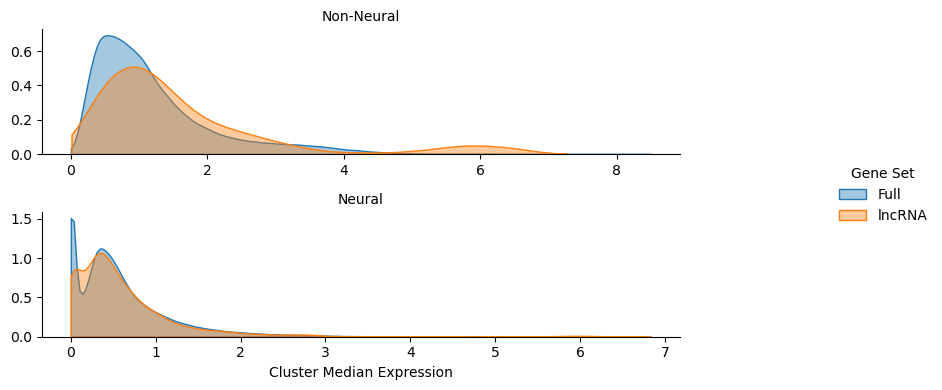

In [26]:
# median ridge plots (tissue and type)
#facet_ridge(df, score_of_interest="median", facet_by="tissue", hue_name="gene_set")
facet_ridge(df, score_of_interest="median", facet_by="type", hue_name="gene_set")
#facet_ridge(df, score_of_interest="median", facet_by="gene_set", hue_name="type")

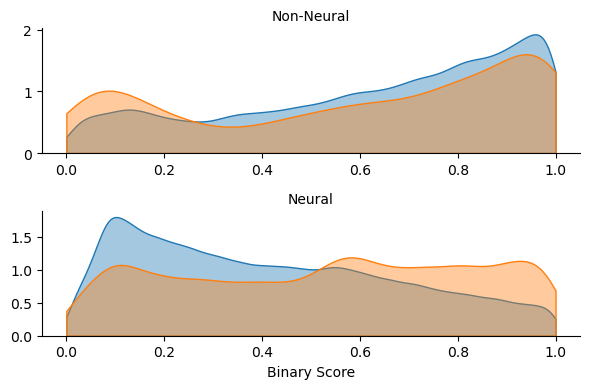

In [27]:
# binary score ridge plots (tissue and type)
#facet_ridge(df, score_of_interest="binary_score", row_name="tissue", hue_name="gene_set")
facet_ridge(df, score_of_interest="binary_score", facet_by="type", hue_name="gene_set")
#facet_ridge(df, score_of_interest="binary_score", row_name="gene_set", hue_name="type")

# Archived Analysis

## CM: Chi-Square Test

In [18]:
df_median.head()

NameError: name 'df_median' is not defined

In [ ]:
# neural and non-neural
contab_medians = pd.crosstab(df_median['gene_set'], df_median['is_zero'])
print(contab_medians)

chi2, p_value, dof, expected = chi2_contingency(contab_medians)
print(f"Chi-Square Statistic: {chi2}")
print(f"P-Value: {p_value}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies: \n{expected}")

In [ ]:
# neural
df_median_neural = df_median[df_median["type"] == "neural"]
contab_medians = pd.crosstab(df_median_neural['gene_set'], df_median_neural['is_zero'])
print(contab_medians)

chi2, p_value, dof, expected = chi2_contingency(contab_medians)
print(f"Chi-Square Statistic: {chi2}")
print(f"P-Value: {p_value}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies: \n{expected}")

In [ ]:
# non-neural
df_median_nonneural = df_median[df_median["type"] == "non-neural"]
contab_medians = pd.crosstab(df_median_nonneural['gene_set'], df_median_nonneural['is_zero'])
print(contab_medians)

chi2, p_value, dof, expected = chi2_contingency(contab_medians)
print(f"Chi-Square Statistic: {chi2}")
print(f"P-Value: {p_value}")
print(f"Degrees of Freedom: {dof}")

## CM: Mann-Whitney U

In [ ]:
# neural and non-neural
mannwhitneyu(df_median[df_median["gene_set"] == "Full"]["median"], 
             df_median[df_median["gene_set"] == "lncRNA"]["median"])

In [ ]:
# neural
mannwhitneyu(df_median_neural[df_median_neural["gene_set"] == "Full"]["median"], 
             df_median_neural[df_median_neural["gene_set"] == "lncRNA"]["median"])

In [ ]:
# non-neural
mannwhitneyu(df_median_nonneural[df_median_nonneural["gene_set"] == "Full"]["median"], 
             df_median_nonneural[df_median_nonneural["gene_set"] == "lncRNA"]["median"])

## Zero Analysis Function

In [ ]:
def zero_analysis(df: pd.DataFrame, score_of_interest: str):
    """
    Args:
        df (pd.DataFrame): Dataframe containing scores and categories to plot.
        score_of_interest (str): Score being analyzed: either "median" or "binary_score".

    Raises:
        ValueError: score_of_interest must be either "median" or "binary_score".
        ValueError: score_of_interest must be a column within the passed df.
    """

    # make sure the score of interest is valid
    valid = {"median", "binary_score"}
    if score_of_interest not in valid:
        raise ValueError("score_of_interest must be one of %r." % valid)  

    # make sure that the passed score of interest is within df
    if score_of_interest not in df.columns:
        raise ValueError("score_of_interest must be within df columns.")
    
    # make sure that the passed df contains 0s
    assert("zero" in df[f"is_zero_{score_of_interest}"],
           "Passed dataframe does not contain any zeroes.")
    
    # start analysis
    print(f"Analyzing {score_of_interest.title()} zeros...")

    # make strata dfs
    df_neural = df[df["type"] == "neural"]
    df_nonneural = df[df["type"] == "non-neural"]

    # both neural and non-neural
    print("--- NEURAL AND NON-NEURAL ---")
    tab_full = pd.crosstab(df['gene_set'], df[f"is_zero_{score_of_interest}"])
    print(tab_full)
    prop_zero_full = tab_full["zero"] / tab_full.sum(axis = 1)
    print(f"Zero Proportions:\n{prop_zero_full}")
    print(f"The lncRNA set has a {(prop_zero_full['lncRNA'] - prop_zero_full['Full'])*100:.3f} percentage point difference from the Full set.")

    ci = confint_proportions_2indep(
        count1 = tab_full.loc["lncRNA", "zero"],
        nobs1=tab_full.loc["lncRNA"].sum(),
        count2 = tab_full.loc["Full", "zero"],
        nobs2=tab_full.loc["Full"].sum(),
        method = "newcomb"
    )
    print(f"Confidence Interval: [{ci[0]*100:.3f}%, {ci[1]*100:.3f}%]")

    rr_full = prop_zero_full["lncRNA"] / prop_zero_full["Full"]
    if rr_full >= 1.0:
        print(f"Zeroes are {(rr_full-1)*100:.3f}% more common in the lncRNA set.")
    else:
        print(f"Zeroes are {rr_full*100:.3f}% less common in the lncRNA set.")

    # neural
    print("\n--- NEURAL ---")
    tab_neural = pd.crosstab(df_neural['gene_set'], df_neural[f"is_zero_{score_of_interest}"])
    print(tab_neural)
    prop_zero_neural = tab_neural["zero"] / tab_neural.sum(axis = 1)
    print(f"Zero Proportions:\n{prop_zero_neural}")
    print(f"The lncRNA set has a {(prop_zero_neural['lncRNA'] - prop_zero_neural['Full'])*100:.3f} percentage point difference from the Full set.")

    ci = confint_proportions_2indep(
        count1 = tab_neural.loc["lncRNA", "zero"],
        nobs1=tab_neural.loc["lncRNA"].sum(),
        count2 = tab_neural.loc["Full", "zero"],
        nobs2=tab_neural.loc["Full"].sum(),
        method = "newcomb"
    )
    print(f"Confidence Interval: [{ci[0]*100:.3f}%, {ci[1]*100:.3f}%]")

    rr_neural = prop_zero_neural["lncRNA"] / prop_zero_neural["Full"]
    if rr_neural >= 1.0:
        print(f"Zeroes are {(rr_neural-1)*100:.3f}% more common in the lncRNA set.")
    else:
        print(f"Zeroes are {rr_neural*100:.3f}% less common in the lncRNA set.")

    # non-neural
    print("\n--- NON-NEURAL ---")
    tab_nonneural = pd.crosstab(df_nonneural['gene_set'], df_nonneural[f"is_zero_{score_of_interest}"])
    print(tab_nonneural)
    prop_zero_nonneural = tab_nonneural["zero"] / tab_nonneural.sum(axis = 1)
    print(f"Zero Proportions:\n{prop_zero_nonneural}")
    print(f"The lncRNA set has a {(prop_zero_nonneural['lncRNA'] - prop_zero_nonneural['Full'])*100:.3f} percentage point difference from the Full set.")

    ci = confint_proportions_2indep(
        count1 = tab_nonneural.loc["lncRNA", "zero"],
        nobs1=tab_nonneural.loc["lncRNA"].sum(),
        count2 = tab_nonneural.loc["Full", "zero"],
        nobs2=tab_nonneural.loc["Full"].sum(),
        method = "newcomb"
    )
    print(f"Confidence Interval: [{ci[0]*100:.3f}%, {ci[1]*100:.3f}%]")

    rr_nonneural = prop_zero_nonneural["lncRNA"] / prop_zero_nonneural["Full"]
    if rr_nonneural >= 1.0:
        print(f"Zeroes are {(rr_nonneural-1)*100:.3f}% more common in the lncRNA set.")
    else:
        print(f"Zeroes are {rr_nonneural*100:.3f}% less common in the lncRNA set.")

In [ ]:
zero_analysis(df, "median")